Q1


In [ ]:
import numpy as np
A=np.array([[1, 1, 0], [1, 0, 1], [0, 1, 1]], dtype=float)
n= A.shape
def gram_schmidt(A):
    m, n = A.shape
    Q = np.zeros((m, n))
    R = np.zeros((n, n))

    for j in range(n):
        v = A[:, j]
        for i in range(j):
            R[i, j] = np.dot(Q[:, i], A[:, j])
            v = v - R[i, j] * Q[:, i]
        R[j, j] = np.linalg.norm(v)
        Q[:, j] = v / R[j, j]
    P= Q@Q.T
    print(Q)
    print(P)
    return Q, R, P
Q_matrix, R_matrix, P_matrix = gram_schmidt(A)
print("Q matrix:")
display(Q_matrix)
print("R matrix:")
display(R_matrix)
print("P matrix:")
display(P_matrix)

identity_matrix = np.eye(Q_matrix.shape[1])
verification = np.allclose(Q_matrix.T @ Q_matrix, identity_matrix)
print(f"Verification of Q.T @ Q = I: {verification}")

[[ 0.70710678  0.40824829 -0.57735027]
 [ 0.70710678 -0.40824829  0.57735027]
 [ 0.          0.81649658  0.57735027]]
[[ 1.00000000e+00 -2.19098475e-16  2.50753550e-16]
 [-2.19098475e-16  1.00000000e+00  4.39774161e-17]
 [ 2.50753550e-16  4.39774161e-17  1.00000000e+00]]
Q matrix:


array([[ 0.70710678,  0.40824829, -0.57735027],
       [ 0.70710678, -0.40824829,  0.57735027],
       [ 0.        ,  0.81649658,  0.57735027]])

R matrix:


array([[1.41421356, 0.70710678, 0.70710678],
       [0.        , 1.22474487, 0.40824829],
       [0.        , 0.        , 1.15470054]])

P matrix:


array([[ 1.00000000e+00, -2.19098475e-16,  2.50753550e-16],
       [-2.19098475e-16,  1.00000000e+00,  4.39774161e-17],
       [ 2.50753550e-16,  4.39774161e-17,  1.00000000e+00]])

Verification of Q.T @ Q = I: True


Q4

Case A: Oscillatory Region (E > V)

When the total energy E is increased much further above the potential V,
the quantity:

k = sqrt(2(E - V))

becomes larger.

This increases the frequency of oscillation of the wavefunction.
Physically, a higher-energy particle has a shorter wavelength and therefore
oscillates more rapidly in space.

CASE B:
Physically, this corresponds to a  thick potential barrier.
The electron has only a very small probability of penetrating deeply into
the barrier.

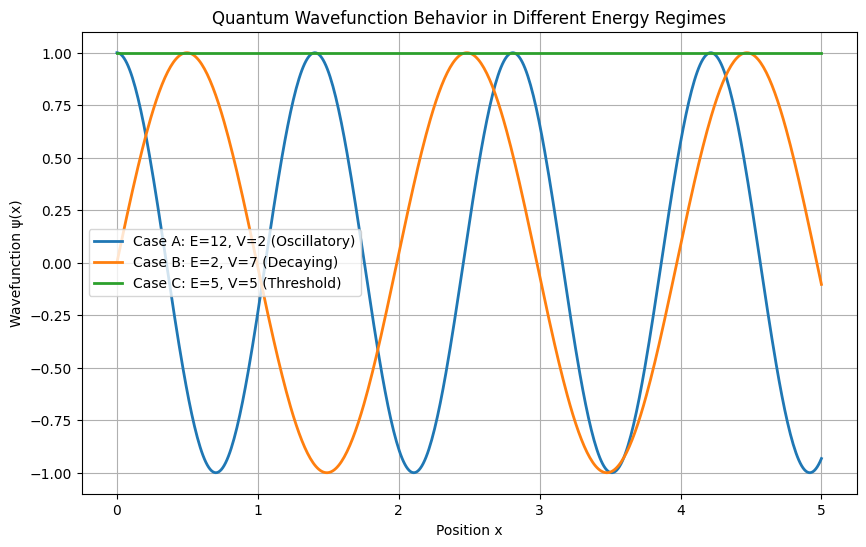

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
x=np.linspace(0,5,500)
def simulate_wavefunction(x, E, V):
  if E > V:
    k= np.sqrt(2*(E-V))
    psi=np.cos(k*x)
  elif E < V:
    k= np.sqrt(2*(V-E))
    psi=np.sin(k*x)
  else:
    # When E == V, psi should be an array of ones with the same shape as x
    psi = np.ones_like(x)
  return psi
psi_A= simulate_wavefunction(x, 12, 2)
psi_B= simulate_wavefunction(x, 2, 7)
psi_C= simulate_wavefunction(x, 5, 5)

plt.figure(figsize=(10, 6))

plt.plot(x, psi_A, label='Case A: E=12, V=2 (Oscillatory)', linewidth=2)
plt.plot(x, psi_B, label='Case B: E=2, V=7 (Decaying)', linewidth=2)
plt.plot(x, psi_C, label='Case C: E=5, V=5 (Threshold)', linewidth=2)

plt.xlabel("Position x")
plt.ylabel("Wavefunction ψ(x)")
plt.title("Quantum Wavefunction Behavior in Different Energy Regimes")

plt.legend()
plt.grid(True)

plt.show()